# 📧 Email Spam Classification using NLP

## Business Problem

Email spam is one of the most common cybersecurity challenges faced by individuals and organizations. Spam emails waste user's time, consume storage resources, and often contain phishing attempts or malicious links.

The objective of this project is to build a machine learning model that automatically classifies emails as **Spam** or **Not Spam** using Natural Language Processing (NLP) techniques.

This project demonstrates an end-to-end machine learning workflow including data preprocessing, feature engineering, model training, evaluation, and deployment using FastAPI and Streamlit.

## Dataset Information

The dataset contains labeled email messages belonging to two classes:

- Spam
- Ham (Not Spam)

Each record contains:

- Email Text
- Label

Goal:

Predict whether a new email belongs to the Spam or Not Spam category.

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import joblib

In [83]:
df=pd.read_csv(r"C:\Users\Admin\Desktop\Shrawani\Projects\Email_Spam_Classifier\data\spam.tsv",sep='\t')

In [84]:
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


## Dataset Overview

In [85]:
df.shape

(5572, 4)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
 2   length   5572 non-null   int64 
 3   punct    5572 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 174.3+ KB


In [87]:
df.describe()

,length,punct
count,5572.000000,5572.000000
mean,80.489950,4.177495
std,59.942907,4.623919
min,2.000000,0.000000
25%,36.000000,2.000000
50%,62.000000,3.000000
75%,122.000000,6.000000
max,910.000000,133.000000


### Data Quality Checks

In [88]:
print("Number of missing values in each column:")
df.isnull().sum()

Number of missing values in each column:


label      0
message    0
length     0
punct      0
dtype: int64

#### Observation:

- The dataset contains no missing values.
- Since all columns are complete, no imputation or removal of missing records was required.
- The dataset is suitable for further preprocessing and model development.

In [89]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 403


In [90]:
df = df.drop_duplicates()

In [91]:
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (5169, 4)


In [92]:
df.duplicated().sum()

np.int64(0)

#### Observation

- The dataset initially contained 403 duplicate records.
- Duplicate entries were removed to improve data quality and prevent the model from learning repeated samples.
- After removing duplicates, the dataset contained 5,169 unique email records.

## Exploratory Data Analysis

### Class Distribution

In [93]:
class_distribution=df["label"].value_counts()
print(class_distribution)

print("\nPercentage Distribution:")
print((class_distribution / len(df) * 100).round(2))

label
ham     4516
spam     653
Name: count, dtype: int64

Percentage Distribution:
label
ham     87.37
spam    12.63
Name: count, dtype: float64


#### Observation

- The majority of email messages belong to the **ham** class, while the **spam** class represents a much smaller portion of the dataset.
- This indicates a **class imbalance**, which is common in real-world spam detection datasets.
- During model evaluation, special attention will be given to **precision**, **recall**, and **F1-score** to ensure the model performs well on the minority (spam) class.

### Message Length Analysis

In [94]:
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


#### Observation

- Ham messages have an average length of approximately **71 characters**, whereas spam messages average around **138 characters**.
- This indicates that spam messages are generally longer than legitimate messages, likely due to promotional content, advertisements, or phishing attempts.
- Ham messages exhibit greater variability in length, while spam messages are more consistent in size.
- Message length appears to be a potentially useful feature for distinguishing spam from ham emails.

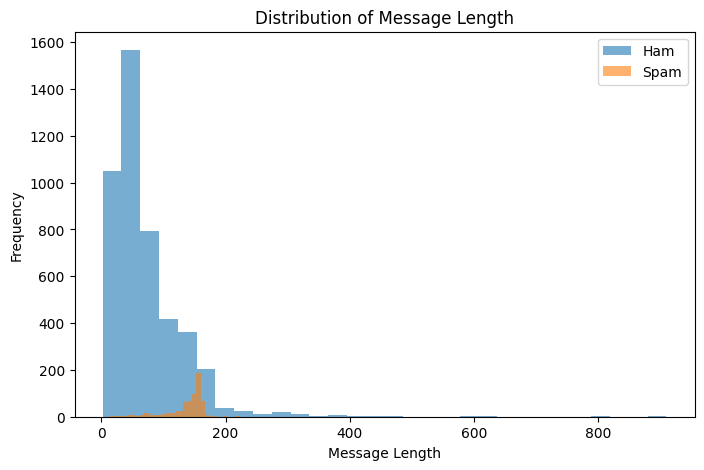

In [95]:
plt.figure(figsize=(8,5))
plt.hist(df[df["label"]=="ham"]["length"], bins=30, alpha=0.6, label="Ham")
plt.hist(df[df["label"]=="spam"]["length"], bins=30, alpha=0.6, label="Spam")
plt.legend()
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Distribution of Message Length")
plt.show()

#### Observation

- The histogram shows that ham messages are generally shorter, whereas spam messages tend to contain more characters.
- Spam messages are concentrated around higher message lengths, indicating that promotional or phishing content is typically longer than legitimate messages.
- Although there is some overlap between the two classes, message length provides useful discriminatory information and can be considered an informative feature during exploratory data analysis.
- Since both classes overlap in certain length ranges, message length alone is insufficient for classification. Therefore, Natural Language Processing techniques such as TF-IDF will be used to capture the textual content of the messages for accurate prediction.

### Punctuation Analysis

In [96]:
df.groupby("label")["punct"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,3.830159,4.488122,0.0,1.0,3.0,5.0,133.0
spam,653.0,5.643185,3.500627,0.0,3.0,5.0,8.0,26.0


#### Observation

- Spam messages contain a higher average number of punctuation marks (5.64) compared to ham messages (3.83).
- This suggests that spam messages often use excessive punctuation to attract the reader's attention or create a sense of urgency.
- Ham messages show greater variability in punctuation usage, indicating more diverse writing styles.
- Although punctuation count provides useful information, it is not sufficient on its own to distinguish spam from ham messages. It should be considered as a supporting feature alongside textual features extracted using NLP techniques.

In [97]:
# Convert labels to numeric

In [98]:
df["label"]=df["label"].map({"ham":0,"spam":1})

In [99]:
X=df["message"]
y=df["label"]

In [100]:
# This is highly imbalanced data, we need to apply data balancing techniques after train test split

In [101]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [102]:
tfidf = TfidfVectorizer(stop_words='english')

In [103]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)


In [104]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [105]:
y_pred = model.predict(X_test_tfidf)

In [106]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9709864603481625


In [107]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[894   0]
 [ 30 110]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       894
           1       1.00      0.79      0.88       140

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [108]:
# model saving

In [109]:
joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [110]:
def predict_email(text):
    tfidf_test = tfidf.transform([text])
    prediction = model.predict(tfidf_test)[0]
    
    return "Spam" if prediction == 1 else "Not Spam"

# Example
print(predict_email("Congratulations! You’ve won a $500 gift card! Click here to claim your prize"))
print(predict_email("Let's meet tomorrow at 10am"))

Spam
Not Spam
